# Workspace Notebook for Ventral Contours Figures

### Authors
* Noah C. Benson
* ...
* Jonathan Winawer

## Configuration

In [220]:
# Change this to match where you have these data on your computer.
filename = '/data/crcns2021/results/proc/ventral_sareas.tsv'

## Initialization

In [221]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import neuropythy as ny
import seaborn as sns

In [222]:
font = {'family': 'arial',
        'size' : 10}
mpl.rc('font', **font)

### Load the Data

In [223]:
# read data and exclude "mean" rater
data = pd.read_csv(filename, sep = '\t')
data_mean = data[data['rater'] == 'mean']
data = data[data['rater'] != 'mean']

data_lh = data[data['hemisphere'] == 'lh']
data_rh = data[data['hemisphere'] == 'rh']

In [224]:
ventral_raters = [
    'BrendaQiu',
    'bogengsong',
    'JiyeongHa',
    'lindazelinzhao',
    'nourahboujaber']

In [226]:
data = data[data['rater'] != 'jennifertepan']

## Figures

The code below in this section is for making the figures of the paper.

### ICC Plot

In [227]:
def find_order(data, roi, hemi, relative=True):
    
    """Returns a list of subject IDs in order of their surface area.
    
    Given a hemisphere ('lh' or 'rh') and an ROI name (like 'hV4'),
    sorts all subjects according to the surface area of the ROI in the
    requested hemisphere and returns the subject IDs in that order.
    """
    # use one rater as reference
    data = data[data['rater'] == 'JiyeongHa']

    if hemi == 'both':
        data = data.groupby('sid', as_index = False).sum(min_count=1, numeric_only = True)
    else:
        data = data[data['hemisphere'] == hemi]

    if type(roi) == list:
        roi_sum = 0
        for r in roi:
            r += '_mm2'
            roi_sum += data[r]

        roi = 'sum'
        data[roi] = roi_sum
    
    else:
        roi += '_mm2'  
        
    if relative:
        data[roi] = data[roi]/data['cortex_mm2']
    
    order = data.sort_values(roi)['sid'].values  
    
    return order

In [240]:
def plot_area (data, roi, hemi, order, relative, sum_up, ax = None, color = 'orange'):
    """Plots by default the percentage of cortical surface area for the given roi and hemisphere.
    
    The ordering of the plots is given by the order parameter.
    """
    if isinstance(roi, list):
        # concatenate data from multiple rois
        roi_sum = 0
        for r in roi:
            r += '_mm2'
            roi_sum += data[r]
        roi = 'sum_mm2'
        data[roi] = roi_sum
    else:
        roi += '_mm2'

    if hemi == 'both':     
        data = data.groupby(['sid', 'rater'], as_index = False).sum(numeric_only = True)
        
        if not sum_up:
            data[roi] = data[roi]/2
            data['cortex_mm2'] = data['cortex_mm2']/2

    else:
        data = data[data['hemisphere'] == hemi]

    # organize the data by order
    data = data.set_index('sid').loc[order]
    ii = np.where(data[roi].values > 0)[0]
    roi_size = data[roi].iloc[ii]
    cortex_size = data['cortex_mm2'].iloc[ii]

    if ax == None:
        ax = plt.gca()

    if relative == True:
        ax.scatter(ii, roi_size/cortex_size*100, s=2, c=color)
    else: # plot in cm^2
        ax.scatter(ii, roi_size/100, s=2, c=color)

In [244]:
# todo: pass a list of roi, color 
def plot_icc (data, roi, 
              hemi='both', 
              relative=True, 
              sum_up=True, 
              ax = None, 
              show_x = False, 
              color = None):
    
    """Plots the ICC plot for a given roi. By default, the function calculates the total surface area of the roi 
        across both hemispheres and plots it as a percentage of the cortical surface area. If `relative` is set 
        to False, the function will plot the surface area of the roi (without calculating it as a percentage of 
        the cortical surface area). If `sum_up` is set to False, the function will instead calculate the average 
        surface area between the two hemispheres. If `hemi` is set to 'lh' or 'rh', the function will plot based on
        the specific hemisphere.
        
    """    
    rater_ids = data['rater'].unique()
    rater_dfs = {}
    
    for rater in rater_ids:
        df = data[data['rater'] == rater]
        rater_dfs[rater] = df
        
    order = find_order(data, roi, hemi)
    
    for i, rater in enumerate(rater_ids):
        plot_area(rater_dfs[rater], roi, hemi, order, relative, sum_up, ax, color[rater])

    if ax == None:
        fig = plt.gcf()
        fig.set_size_inches(20, 10)
        ax = plt.gca()
        
    if show_x:
        # set xlabel
        ax.set_xlabel('Subject Index [sorted by one researcher]', fontsize=12)
    
    # set grid
    ax.set_xticks(range(181))
    ax.grid(axis='x', color='0.8', linestyle='-', lw=0.1)
    ax.set_title(roi[:3], fontsize=12)
    ax.set_xticklabels([])
    ax.yaxis.set_tick_params(labelsize=10)

In [245]:
order = find_order(data, 'hV4', 'lh')

How surface area is calculated under different states when `hemi == 'both'`:\
\
if `sum_up == True & relative == True`:    $area = {roi_{left} + roi_{right} \over cortex_{left} + cortex_{right}} * 100$\
\
if `sum_up == False & relative == True`:   $area = {{(roi_{left} + roi_{right})/2} \over {(cortex_{left} + cortex_{right})/2}} * 100$\
\
if `sum_up == True & relative == False`:   $area = {roi_{left} + roi_{right}}$\
\
if `sum_up == False & relative == False`:   $area = {{roi_{left} + roi_{right}}\over2}$\
\
note: the plot 'looks' the same regardless of `sum_up`'s state: when `relative == False`, the only difference is the values on the y-axis; when `relative == True`, the plots are exactly the same

In [247]:
rater_color = {'BrendaQiu': '#377eb8', 
               'JiyeongHa': '#999999', 
               'bogengsong': '#000000', 
               'jennifertepan': '#ff7f00',
               'lindazelinzhao': '#e41a1c', 
               'nourahboujaber': '#984EA3',
               'mean':'k'}

fig, axes = plt.subplots(3,1, figsize = (7,7), dpi = 1200)
fig.subplots_adjust(0,0,1,1,0,0.2)

plot_icc (data, 'hV4', relative = True, sum_up = False, ax = axes[0], color = rater_color)
plot_icc (data, 'VO1', relative = True, sum_up = False, ax = axes[1], color = rater_color)
plot_icc (data, 'VO2', relative = True, sum_up = False, ax = axes[2], show_x = True, color = rater_color)

for ax in axes:
    ax.set_xlim((-1, 181))
    ax.spines['top'].set_visible (False)
    ax.spines['right'].set_visible (False)
    ax.spines['bottom'].set_visible (False)
    ax.spines['left'].set_visible (False)
    ax.plot([0,180],[0,0],'k-', lw=1) 
    
axes[0].set_ylim((0,1.5))
axes[0].plot([-1, -1], [0,1.5],'k-', lw=1)
axes[1].set_ylim((0,0.8)) 
axes[1].plot([-1, -1], [0,0.8],'k-', lw=1)
axes[2].set_ylim((0,0.8))
axes[2].plot([-1, -1], [0,0.8],'k-', lw=1)


axes[1].set_ylabel('Relative Visual Area Size [% of cortex]', labelpad=12, fontsize=12)
plt.savefig ('icc.pdf', bbox_inches='tight')

In [142]:
rs = {}
rs_sum = {}
for area in ['hV4', 'VO1', 'VO2']:
    print(area)
    r_list_1 = []
    r_list_1_sum= []
    
    for rater1 in ventral_raters:
        r_list_2 = []
        r_list_2_sum = []
        for rater2 in ventral_raters:
            
            df_1 = data[data['rater'] == rater1]
            df_2 = data[data['rater'] == rater2]
            
            r1col = df_1[area + '_mm2'].values
            r2col = df_2[area + '_mm2'].values
            
            ii = np.isfinite(r1col) & np.isfinite(r2col)
            r = np.corrcoef(r1col[ii], r2col[ii])[0,1]
            r_list_2.append(r)
            print('-', r, rater1, rater2)

            # summing left and right hemisphere data
            df_1_sum = data[data['rater'] == rater1].groupby(['sid']).sum(numeric_only=True, min_count=2)
            df_2_sum = data[data['rater'] == rater2].groupby(['sid']).sum(numeric_only=True, min_count=2)
            
            r1col_sum = df_1_sum[area + '_mm2']
            r2col_sum = df_2_sum[area + '_mm2']
                    
            ii2 = np.isfinite(r1col_sum) & np.isfinite(r2col_sum)
            r2 = np.corrcoef(r1col_sum[ii2], r2col_sum[ii2])[0,1]
            r_list_2_sum.append(r2)
            print(' ', r2, rater1, rater2)
       
        r_list_1.append(r_list_2)
        r_list_1_sum.append(r_list_2_sum)
        
    rs[area] = np.array(r_list_1)
    rs_sum[area] = np.array(r_list_1_sum)


hV4
- 1.0 BrendaQiu BrendaQiu
  1.0 BrendaQiu BrendaQiu
- 0.6434724100823833 BrendaQiu bogengsong
  0.7242082782686471 BrendaQiu bogengsong
- 0.6621807360274766 BrendaQiu JiyeongHa
  0.7251196045998062 BrendaQiu JiyeongHa
- 0.6630523532868003 BrendaQiu lindazelinzhao
  0.7340643665732861 BrendaQiu lindazelinzhao
- 0.5515564175478488 BrendaQiu nourahboujaber
  0.5636494047186504 BrendaQiu nourahboujaber
- 0.5615781813677801 BrendaQiu jennifertepan
  0.6022396453757306 BrendaQiu jennifertepan
- 0.6434724100823833 bogengsong BrendaQiu
  0.724208278268647 bogengsong BrendaQiu
- 1.0 bogengsong bogengsong
  0.9999999999999998 bogengsong bogengsong
- 0.6652135175077328 bogengsong JiyeongHa
  0.7186614425565289 bogengsong JiyeongHa
- 0.6099056368382143 bogengsong lindazelinzhao
  0.68317875879589 bogengsong lindazelinzhao
- 0.5092166995150287 bogengsong nourahboujaber
  0.5594592213095284 bogengsong nourahboujaber
- 0.587418619976252 bogengsong jennifertepan
  0.6521913795412694 bogengsong jen

In [30]:
def plot_rs(rs, ax=None):
    
    x = np.triu(rs['hV4'], 1).flatten()
    y = np.triu(rs['VO1'], 1).flatten()
    z = np.triu(rs['VO2'], 1).flatten()

    x = x[x!=0]
    y = y[y!=0]
    z = z[z!=0]

    ax.plot(x, y, 'ro', label='hV4-VO1')
    ax.plot(x, z, 'go', label='hV4-VO2')
    ax.plot(y, z, 'bo', label='VO1-VO2')
    
    ax.legend()

Text(0.5, 1.0, 'sum')

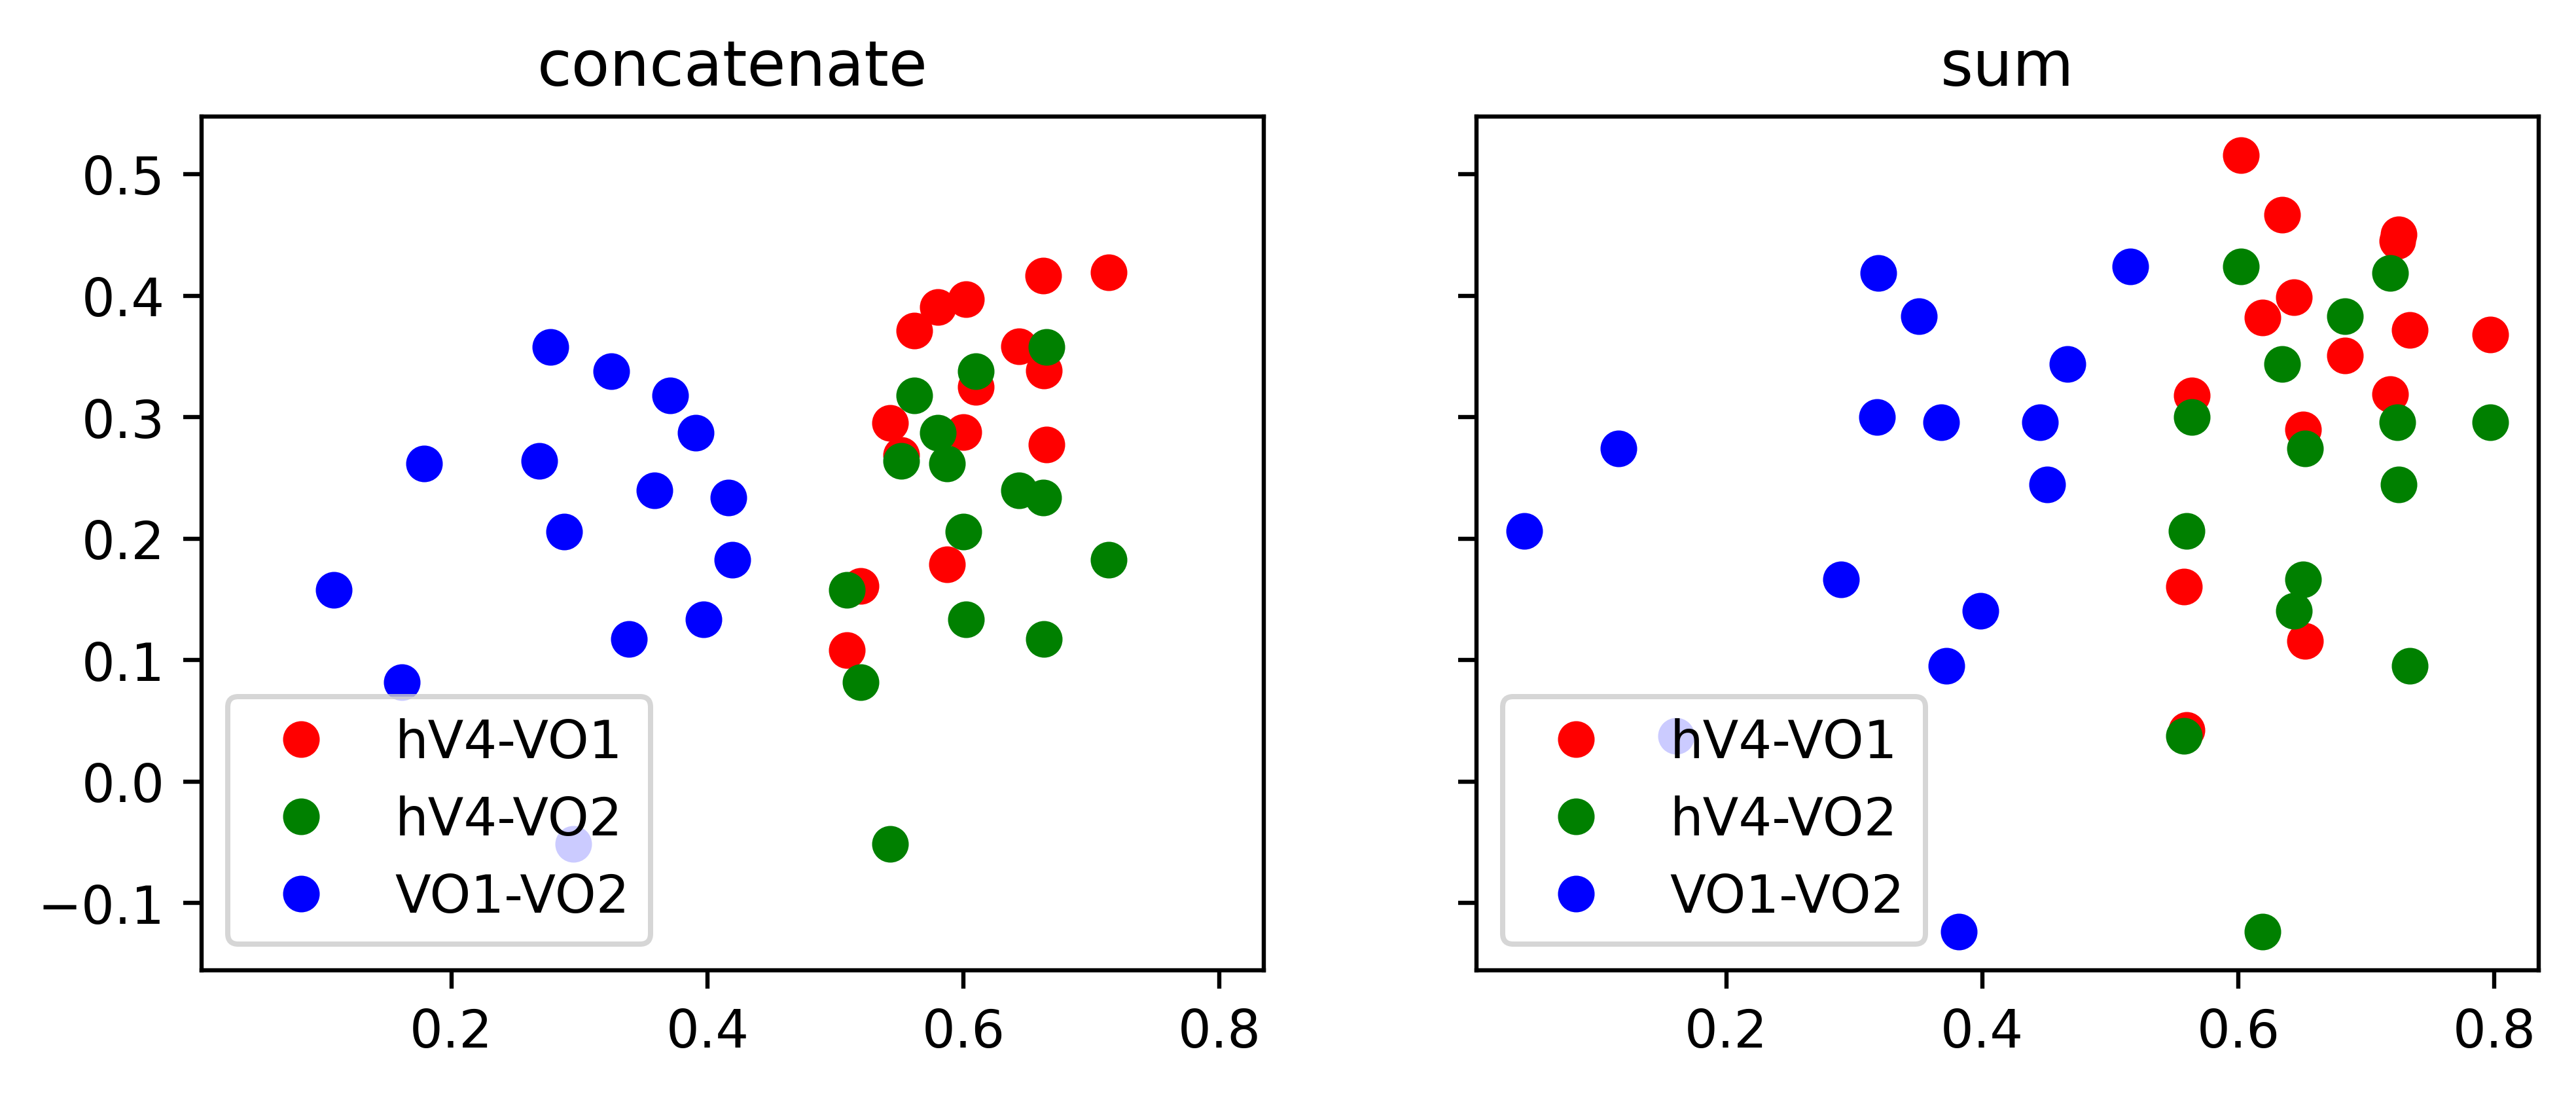

In [31]:
(fig, ax) = plt.subplots(1, 2,  figsize=(8,3), dpi=72*8, sharex=True, sharey=True)
plot_rs(rs, ax[0])
plot_rs(rs_sum, ax[1])
ax[0].set_title('concatenate') # lh and rh data treated as individual observations
ax[1].set_title('sum') # sum lh and rh data into one observation

In [51]:
def plot_box(rs, ax=None, title=None):
    
    xs = []
    ys = []
    zs = []
    
    for r in rs:
        x = np.triu(r['hV4'], 1).flatten()
        y = np.triu(r['VO1'], 1).flatten()
        z = np.triu(r['VO2'], 1).flatten()
    
        x = x[x!=0]
        y = y[y!=0]
        z = z[z!=0]
        
        xs.append(x)
        ys.append(y)
        zs.append(z)
        
    
    plt.boxplot([xs[0], xs[1], ys[0], ys[1], zs[0], zs[1]], 
               labels = ['hV4_concat', 'hV4_sum', 'VO1_concat', 'VO1_sum', 'VO2_concat', 'VO2_sum'])
    plt.title(title)

Text(0, 0.5, "Pearson's r")

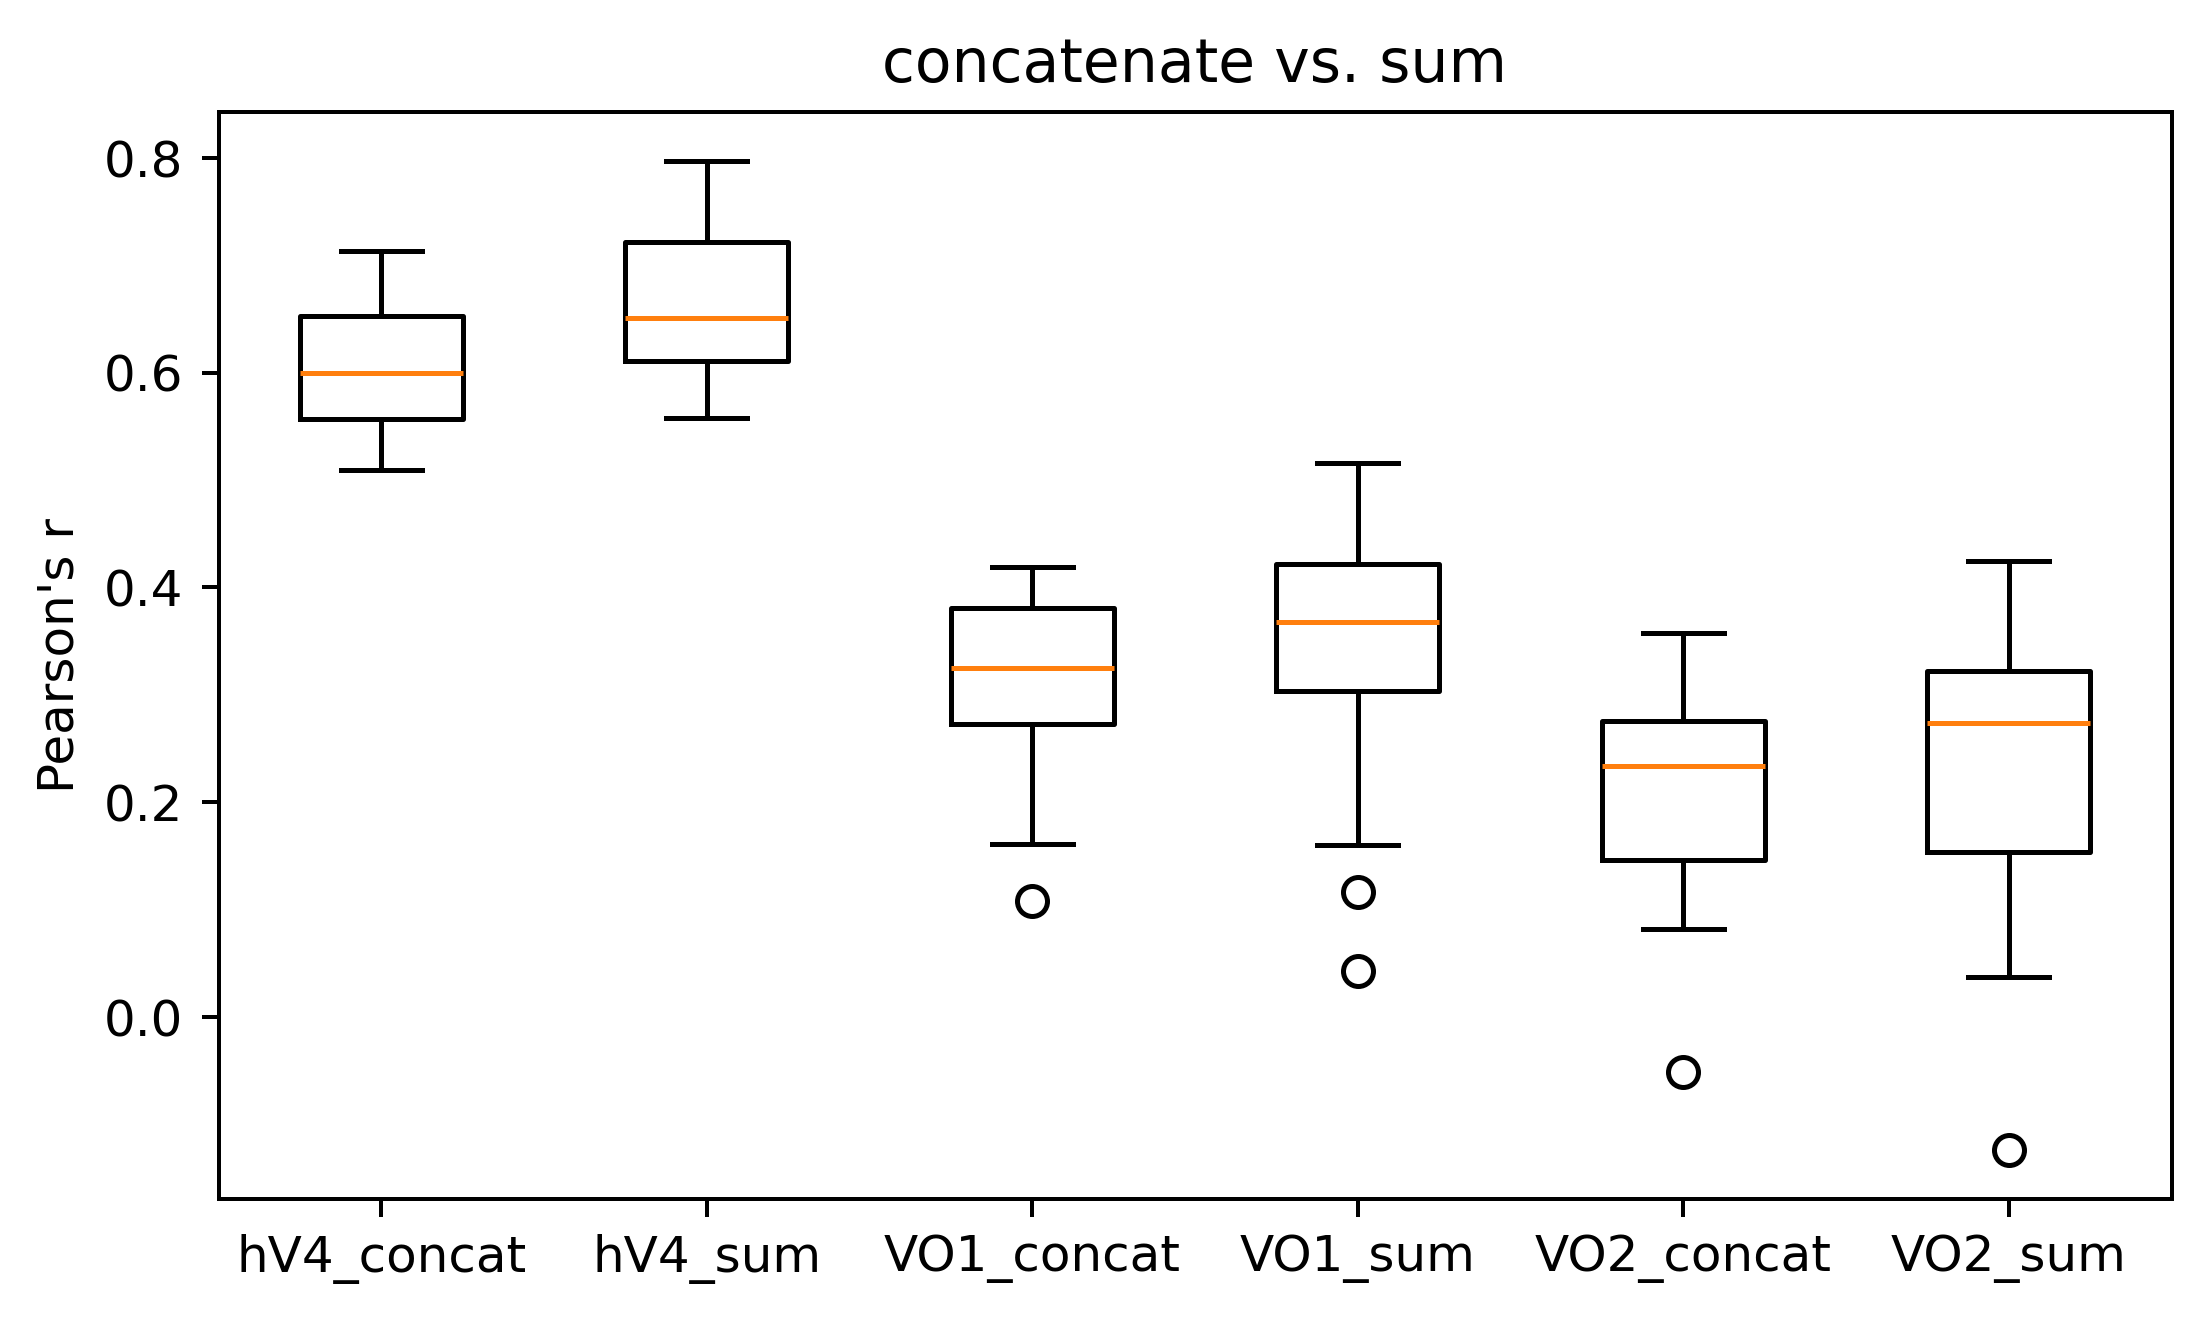

In [65]:
plt.figure(figsize=(7,4), dpi=72*5)
plot_box([rs, rs_sum], title='concatenate vs. sum')
plt.ylabel('Pearson\'s r')

In [15]:
rater1 = data[data['rater'] == 'jennifertepan']
rater2 = data[data['rater'] == 'bogengsong']

h_colors = {'rh': 'red', 'lh': 'blue'}
colors = [h_colors[h] for h in rater1['hemisphere']]

In [16]:
rater1

,rater,sid,hemisphere,hV4_mm2,hV4_percent,VO1_mm2,VO1_percent,VO2_mm2,VO2_percent,cortex_mm2
1810,jennifertepan,100610,lh,693.670349,0.670405,212.833145,0.205695,232.919220,0.225107,103470.296875
1811,jennifertepan,100610,rh,694.284424,0.668335,64.522514,0.062111,361.055298,0.347561,103882.664062
1812,jennifertepan,102311,lh,823.615234,0.852860,296.210083,0.306728,242.236633,0.250838,96570.992188
1813,jennifertepan,102311,rh,919.419861,0.946051,239.995651,0.246947,96.515778,0.099311,97185.007812
1814,jennifertepan,102816,lh,882.795166,0.998140,378.396301,0.427837,195.879532,0.221473,88444.023438
...,...,...,...,...,...,...,...,...,...,...
2167,jennifertepan,971160,rh,324.831055,0.310754,616.395264,0.589682,138.882294,0.132864,104530.054688
2168,jennifertepan,973770,lh,419.938354,0.432322,349.660217,0.359971,133.088684,0.137013,97135.625000
2169,jennifertepan,973770,rh,483.604065,0.489929,288.768066,0.292545,155.482193,0.157516,98709.078125
2170,jennifertepan,995174,lh,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
rater1.groupby('sid').sum(numeric_only=True)

,hV4_mm2,hV4_percent,VO1_mm2,VO1_percent,VO2_mm2,VO2_percent,cortex_mm2
sid,,,,,,,
100610,1387.954773,1.338741,277.355659,0.267806,593.974518,0.572668,207352.960938
102311,1743.035095,1.798911,536.205734,0.553675,338.752411,0.350149,193756.000000
102816,1613.525818,1.819208,547.500885,0.617847,391.428879,0.441197,177441.648438
104416,1156.357666,1.214247,191.691902,0.201312,614.468643,0.645294,190459.187500
105923,1941.941650,1.918098,383.208481,0.378488,354.075943,0.349729,202489.734375
...,...,...,...,...,...,...,...
958976,603.921265,0.635344,821.303009,0.865902,221.441933,0.233057,190294.945312
966975,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
971160,939.487915,0.904930,867.935211,0.832841,266.427994,0.256159,207976.921875


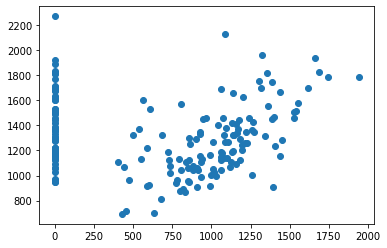

In [18]:
plt.scatter(rater1.groupby('sid').sum()['hV4_mm2'], rater2.groupby('sid').sum()['hV4_mm2'])

In [19]:
rater1.groupby('sid').sum(numeric_only=True, min_count=2)

,hV4_mm2,hV4_percent,VO1_mm2,VO1_percent,VO2_mm2,VO2_percent,cortex_mm2
sid,,,,,,,
100610,1387.954773,1.338741,277.355659,0.267806,593.974518,0.572668,207352.960938
102311,1743.035095,1.798911,536.205734,0.553675,338.752411,0.350149,193756.000000
102816,1613.525818,1.819208,547.500885,0.617847,391.428879,0.441197,177441.648438
104416,1156.357666,1.214247,191.691902,0.201312,614.468643,0.645294,190459.187500
105923,1941.941650,1.918098,383.208481,0.378488,354.075943,0.349729,202489.734375
...,...,...,...,...,...,...,...
958976,603.921265,0.635344,821.303009,0.865902,221.441933,0.233057,190294.945312
966975,NaN,NaN,NaN,NaN,NaN,NaN,NaN
971160,939.487915,0.904930,867.935211,0.832841,266.427994,0.256159,207976.921875


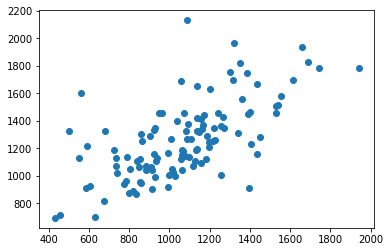

In [20]:
plt.scatter(rater1.groupby('sid').sum(min_count=2)['hV4_mm2'], rater2.groupby('sid').sum(min_count=2)['hV4_mm2'])

### Violin Plot

#### Reload the Data

In [90]:
data_v13 = ny.data['hcp_lines'].surface_area_dataframe
data_v13 = data_v13 [data_v13['anatomist']=='mean']
data_v13 = data_v13 [['roiLV1','roiRV1','roiLV2','roiRV2','roiLV3','roiRV3']]

/home/brendaqiu/.conda/envs/cnn/lib/python3.10/site-packages/neuropythy/datasets/hcp_lines.py:579: UserWarning: hcp-lines: Failed to read dataframe file: /data/hcp/lines/normalized/surface_areas.hdf5
  warnings.warn('hcp-lines: Failed to read dataframe file: %s' % p)


In [91]:
data_v13

,roiLV1,roiRV1,roiLV2,roiRV2,roiLV3,roiRV3
4,2182.648869,1860.693153,1728.088569,1659.008599,1119.816370,1172.995850
9,1979.312683,2051.494042,1669.270603,1849.540834,1064.189967,1352.400127
14,1153.694862,1116.527387,1118.138452,1207.856324,872.083832,865.760388
19,1231.193647,1205.712993,1271.163609,1355.516790,1001.229745,1008.570664
24,1022.975665,1022.367207,1164.040613,1111.529883,886.230702,782.037635
...,...,...,...,...,...,...
884,1444.961363,1273.361188,1335.570071,1290.200584,1114.681135,1045.837380
889,1136.901352,974.767644,1026.256552,870.247724,875.898848,904.958032
894,NaN,808.052458,NaN,773.187416,NaN,691.081453
899,1338.753442,1381.183600,1248.840014,1237.964415,1060.750740,944.633979


In [92]:
# Reorganize data

data_violin =  {'hemisphere' : [],
                'roi' : [],
                'surface area' : [],
                 }

for i in data_v13.columns:
    if i[3:4] == 'L':
        hemi = 'lh'
    else:
        hemi = 'rh'
    
    for index, row in data_v13.iterrows():
        data_violin ['hemisphere'].append (hemi)
        data_violin ['roi'].append (i[-2:])
        data_violin ['surface area'].append (row [i]) 

for index, row in data_mean.iterrows():
    for roi in ['hV4_mm2', 'VO1_mm2', 'VO2_mm2']:
        data_violin ['hemisphere'].append (row ['hemisphere'])
        data_violin ['roi'].append (roi)
        data_violin ['surface area'].append (row [roi])     

data_violin = pd.DataFrame(data_violin)

In [93]:
data_mean

,rater,sid,hemisphere,hV4_mm2,hV4_percent,VO1_mm2,VO1_percent,VO2_mm2,VO2_percent,cortex_mm2
2172,mean,100610,lh,793.065979,0.766467,249.325195,0.240963,246.177490,0.237921,103470.296875
2173,mean,100610,rh,696.210083,0.670189,203.665619,0.196054,325.754333,0.313579,103882.664062
2174,mean,102311,lh,799.302551,0.827684,288.963715,0.299224,277.241089,0.287085,96570.992188
2175,mean,102311,rh,931.787964,0.958777,342.286163,0.352201,184.105927,0.189439,97185.007812
2176,mean,102816,lh,976.606079,1.104208,383.498962,0.433606,224.987976,0.254385,88444.023438
...,...,...,...,...,...,...,...,...,...,...
2529,mean,971160,rh,451.890381,0.432307,385.193146,0.368500,332.992676,0.318562,104530.054688
2530,mean,973770,lh,543.127747,0.559144,352.113953,0.362497,196.547089,0.202343,97135.625000
2531,mean,973770,rh,643.400391,0.651815,318.638794,0.322806,259.358032,0.262750,98709.078125
2532,mean,995174,lh,899.431702,0.944045,287.985291,0.302270,271.999725,0.285491,95274.210938


In [94]:
data_violin

,hemisphere,roi,surface area
0,lh,V1,2182.648869
1,lh,V1,1979.312683
2,lh,V1,1153.694862
3,lh,V1,1231.193647
4,lh,V1,1022.975665
...,...,...,...
2167,lh,VO1_mm2,287.985291
2168,lh,VO2_mm2,271.999725
2169,rh,hV4_mm2,1011.385559
2170,rh,VO1_mm2,414.509796


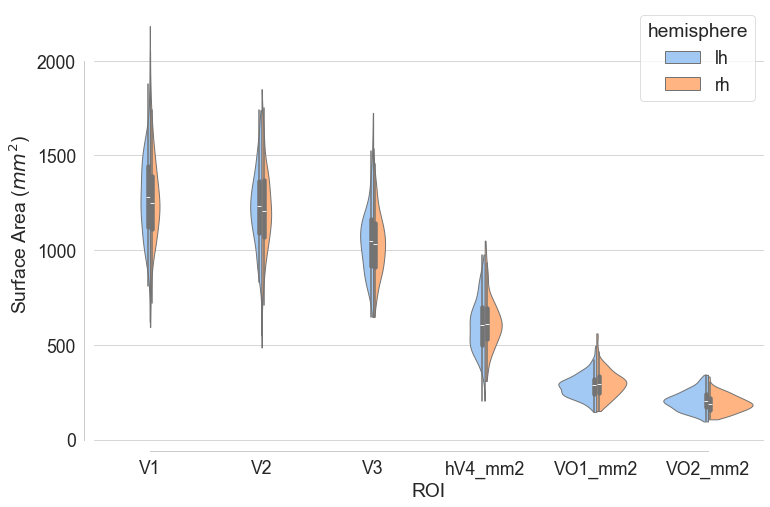

In [95]:
# plot violin
sns.set_theme(context = 'paper', style = 'whitegrid', font_scale = 2, rc={'figure.figsize':(12, 8)})

ax = sns.violinplot(x='roi', y ='surface area', hue="hemisphere", cut = 0, 
               data = data_violin, palette="pastel", split=True, saturation=1)
ax.set_xlabel ('ROI')
ax.set_ylabel ('Surface Area ($mm^2$)')

sns.despine(offset=10, trim=True);
